In [13]:
import requests
import pandas as pd
from io import StringIO
from requests.auth import HTTPBasicAuth

# El '0' indica "mi usuario actual"
url = "https://intervals.icu/api/v1/athlete/0/athlete-summary"

# Reemplaza con tu clave real obtenida en /settings
api_key = "1347lyp9p4meza7lyd3sar4qu" 

# La autenticación usa 'API_KEY' como usuario y tu clave como contraseña
auth = HTTPBasicAuth('API_KEY', api_key)

response = requests.get(url, auth=auth)

if response.status_code == 200:
    atletas = response.json()
      # Imprime la respuesta completa para depuración
    # Quitar duplicados por athlete_id y nombre
    atletas = list({(a.get('athlete_id'), a.get('athlete_name')): a for a in atletas}.values())

   

    meta_burgos = pd.read_csv('data/burgos.csv', sep=';')
    meta_burgos['intervals_id'] = meta_burgos['intervals_id'].astype(str)
    nombres_burgos = dict(zip(meta_burgos['intervals_id'], meta_burgos['Name']))

    for atleta in atletas:
        athlete_id = str(atleta.get('athlete_id'))
        atleta['athlete_name'] = nombres_burgos.get(athlete_id, atleta.get('athlete_name'))

    # Filtrar solo atletas con carrera=1 en burgos.csv
    ids_carrera = set(meta_burgos.loc[meta_burgos['carrera'] == 0, 'intervals_id'].astype(str))
    atletas = [a for a in atletas if str(a.get('athlete_id')) in ids_carrera]

    print(f"Se encontraron {len(atletas)} atletas únicos.")
    print(atletas)
else:
    print(f"Error: {response.status_code}")


Se encontraron 8 atletas únicos.
[{'count': 0, 'time': 0, 'moving_time': 0, 'elapsed_time': 0, 'calories': 0, 'total_elevation_gain': 0.0, 'training_load': 0, 'srpe': 0, 'distance': 0.0, 'eftp': None, 'eftpPerKg': None, 'date': '2026-05-04', 'athlete_id': 'i547906', 'athlete_name': 'Adrian Fajardo', 'email': None, 'external_id': None, 'fitness': 34.849262, 'fatigue': 12.665995, 'form': 22.183268, 'rampRate': -6.320278, 'weight': None, 'timeInZones': [0, 0, 0, 0, 0, 0, 0, 0], 'timeInZonesTot': 0, 'byCategory': [{'count': 0, 'time': 0, 'moving_time': 0, 'elapsed_time': 0, 'calories': 0, 'total_elevation_gain': 0.0, 'training_load': 0, 'srpe': 0, 'distance': 0.0, 'eftp': 304.02002, 'eftpPerKg': None, 'category': 'Ride'}], 'mostRecentWellnessId': '2026-05-04'}, {'count': 0, 'time': 0, 'moving_time': 0, 'elapsed_time': 0, 'calories': 0, 'total_elevation_gain': 0.0, 'training_load': 0, 'srpe': 0, 'distance': 0.0, 'eftp': None, 'eftpPerKg': None, 'date': '2026-05-04', 'athlete_id': 'i93850', 

In [ ]:
print("\n=== NOMBRES DE ATLETAS ===")
for atleta in atletas:
    print(f"- {atleta['athlete_name']} - id {atleta['athlete_id']}")


=== NOMBRES DE ATLETAS ===
- Georgios Bouglas - id i554492
- Jose Luis Faura - id i547904
- Jose Manuel Diaz - id i547157
- Mario Aparicio - id i554068
- Martin Rey - id i554086


: 

== NOMBRES DE ATLETAS ===
- Adrian Fajardo - id i547906
- Alex Mayer - id i93850
- CarlosGarcia11 - id i495562
- Eric Fagundez - id i553889
- Georgios Bouglas - id i554492
- Jose Luis Faura - id i547904
- Josemanueldiaz - id i547157
- LorenzoQ - id i545517
- Maciaspetro - id i281806
- Martin Rey - id i554086
- Sinuhé - id i545516
- Vojtěch Kmínek - id i554486
- oka_ander - id i546414
- Mario Aparicio - id i554068


In [ ]:
from datetime import datetime, timedelta
 
print("\n=== ESTADÍSTICAS DE ENTRENAMIENTO ===")
for i, atleta in enumerate(atletas, 1):
    nombre = atleta['athlete_name']
    fecha = atleta['date']
    distancia_m = atleta['distance']  # en metros
    distancia_km = distancia_m / 1000  # convertir a km
    tiempo_s = atleta['moving_time']  # en segundos
    calorias = atleta.get('calories', 0)
    kilojulios = calorias * 4.184  # 1 kcal = 4.184 kJ
    peso = atleta.get('weight')
    print(f"\n{i}. {nombre} - Fecha: {fecha}")
    # Convertir tiempo a hh:mm:ss
    horas = tiempo_s // 3600
    minutos = (tiempo_s % 3600) // 60
    segundos = tiempo_s % 60
    tiempo_formateado = f"{int(horas):02d}:{int(minutos):02d}:{int(segundos):02d}"
    
    # Calcular velocidad media en km/h
    tiempo_h = tiempo_s / 3600
    velocidad_media = distancia_km / tiempo_h if tiempo_h > 0 else 0
    
    # Calcular trabajo/peso (en kJ/kg)
    trabajo_por_peso = kilojulios / peso if peso and peso > 0 else 65

    print(f"{nombre}, {fecha}, {distancia_km:.2f}km, {trabajo_por_peso:.2f}kj/kg")
    
    # Configurar rango de fechas (últimos 90 días)
    oldest = (datetime.now() - timedelta(days=3)).strftime('%Y-%m-%d')
    newest = datetime.now().strftime('%Y-%m-%d')

    url_actividades = f"https://intervals.icu/api/v1/athlete/{atleta['athlete_id']}/activities?oldest={oldest}&newest={newest}"

    response_actividades = requests.get(url_actividades, auth=auth)
    print()
    if response_actividades.status_code == 200:
        actividades = response_actividades.json()
        print(f"\n=== ACTIVIDADES DEL ATLETA ===")
        print(f"Se encontraron {len(actividades)} actividades.\n")
    
        for i, actividad in enumerate(actividades, 1):
            fuente = actividad.get('source', 'No se encontró la fuente de datos')
            print(fuente)
            fecha = actividad.get('start_date_local', 'N/A')
            nombre = actividad.get('name', 'Sin nombre')
            tipo_deporte = actividad.get('type', 'N/A')
            distancia = (actividad.get('distance') or 0) / 1000  # convertir a km
            tiempo = actividad.get('moving_time') or 0
            id_actividad = actividad.get('id')
            if fuente == 'STRAVA' and id_actividad:
                url = f"https://intervals.icu/api/v1/activity/{id_actividad}/fit-file"

                print(f"Descargando archivo FIT para la actividad {id_actividad}...")
                # Reemplaza con tu clave real obtenida en /settings
                api_key = "1347lyp9p4meza7lyd3sar4qu" 

                # La autenticación usa 'API_KEY' como usuario y tu clave como contraseña
                auth = HTTPBasicAuth('API_KEY', api_key)
                # 3. Petición GET
                responsefit = requests.get(url, auth=auth)
                print(responsefit.json())
                if responsefit.status_code == 200:
                    # 4. Guardar como contenido binario (.content) y con extensión .fit.gz
                    nombre_archivo = f"actividad_{id_actividad}.fit.gz"
    
                    with open(nombre_archivo, "wb") as archivo:
                        archivo.write(response.content)
                        
                        print(f"¡Éxito! Archivo guardado como '{nombre_archivo}'")
                        print("Nota: El archivo está comprimido. Necesitarás descomprimirlo para obtener el .fit crudo.")
                        print("   FIT no disponible: Intervals.icu no permite leer actividades de Strava vía esta API.")
            # Convertir tiempo a hh:mm:ss
            horas_a = tiempo // 3600
            minutos_a = (tiempo % 3600) // 60
            segundos_a = tiempo % 60
            tiempo_formateado_a = f"{int(horas_a):02d}:{int(minutos_a):02d}:{int(segundos_a):02d}"
        
            # Calcular velocidad o ritmo según el tipo de deporte
            if tipo_deporte == 'Run' and distancia > 0:
                # Para Run: calcular ritmo en min/km
                minutos_por_km = tiempo / 60 / distancia
                min_ritmo = int(minutos_por_km)
                seg_ritmo = int((minutos_por_km - min_ritmo) * 60)
                ritmo_str = f"{min_ritmo}:{seg_ritmo:02d} min/km"
                velocidad_str = ritmo_str
            else:
                # Para otros deportes: velocidad en km/h
                tiempo_h_a = tiempo / 3600
                velocidad = (distancia / tiempo_h_a) if tiempo_h_a > 0 else 0
                velocidad_str = f"{velocidad:.2f} km/h"
        
            print(f"{i}. {fecha} - {nombre} ({tipo_deporte})")
            print(f"   Distancia: {distancia:.2f} km | Tiempo: {tiempo_formateado_a} | Ritmo/Velocidad: {velocidad_str}")
        
            if not id_actividad:
                print("   Actividad sin id, se omiten detalles y curva de potencia.")
                print()
                continue

            # Obtener detalles completos de la actividad para interval_summary
            url_detalle = f"https://intervals.icu/api/v1/athlete/{atleta['athlete_id']}/activities/{id_actividad}"
            response_detalle = requests.get(url_detalle, auth=auth)
            
            if response_detalle.status_code == 200:
                detalle_act = response_detalle.json()
                if isinstance(detalle_act, list) and len(detalle_act) > 0:
                    detalle_act = detalle_act[0]
                
                # Mostrar interval_summary si existe
                if 'interval_summary' in detalle_act and detalle_act['interval_summary']:
                    print(f"   Intervalos: {', '.join(detalle_act['interval_summary'])}")
            
            url_power = f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv"
            response_power = requests.get(url_power, auth=auth)

            if response_power.status_code == 422:
                print("   Curva de potencia no disponible vía API para esta actividad.")
                print()
                continue

            if response_power.status_code != 200:
                print(f"   Error al obtener power-curve: {response_power.status_code}")
                print()
                continue

            # Parsear CSV de power-curve y extraer 300s, 600s, 1200s
            try:
                df_curve = pd.read_csv(StringIO(response_power.text))
            except Exception as e:
                print(f"   No se pudo parsear power-curve.csv: {e}")
                print()
                continue

            cols = {c.lower(): c for c in df_curve.columns}
            sec_col = next((cols[c] for c in cols if 'sec' in c), None)
            watts_col = next((cols[c] for c in cols if 'watt' in c or c == 'w'), None)

            if sec_col is None or watts_col is None:
                print(f"   Columnas no detectadas en CSV. Columnas: {list(df_curve.columns)}")
                print()
                continue

            df_curve[sec_col] = pd.to_numeric(df_curve[sec_col], errors='coerce')
            df_curve[watts_col] = pd.to_numeric(df_curve[watts_col], errors='coerce')
            df_curve = df_curve.dropna(subset=[sec_col, watts_col])

            objetivos = [30,120,300, 600, 1200]
            mejores = {}

            for s in objetivos:
                fila = df_curve[df_curve[sec_col] == s]
                if not fila.empty:
                    mejores[s] = float(fila[watts_col].max())
                else:
                    mejores[s] = None

            print(
                "   Mejores potencias -> "
                f"30s: {f'{mejores[30]:.0f}W' if mejores[30] is not None else 'N/D'} | "
                f"2': {f'{mejores[120]:.0f}W' if mejores[120] is not None else 'N/D'} | "
                f"5': {f'{mejores[300]:.0f}W' if mejores[300] is not None else 'N/D'} | "
                f"10': {f'{mejores[600]:.0f}W' if mejores[600] is not None else 'N/D'} | "
                f"20': {f'{mejores[1200]:.0f}W' if mejores[1200] is not None else 'N/D'}"
            )
            print()
    else:
        print(f"Error al obtener actividades: {response_actividades.status_code}")
        print(response_actividades.text)

    url_wellness = f"https://intervals.icu/api/v1/athlete/{atleta['athlete_id']}/wellness"
    url_power_curves = f"https://intervals.icu/api/v1/athlete/{atleta['athlete_id']}/power-hr-curve?start={oldest}&end={newest}"
    params = {"oldest": oldest, "newest": newest}
    response_power = requests.get(url_power_curves, auth=auth, params=params)
    print(response_power.json())
    auth = HTTPBasicAuth('API_KEY', api_key)
    
    params = {"oldest": oldest, "newest": newest}
    response = requests.get(url_wellness, auth=auth, params=params)

    if response.status_code == 200:
        datos_bienestar = response.json()
        print(response.json())
        print(f"\n=== DATOS DE BIENESTAR DEL ATLETA ===")
        print(f"Se obtuvieron datos de {len(datos_bienestar)} días.{oldest} - {newest}")
        # Procesar la lista de objetos devuelta
        for dia in datos_bienestar:
            print(dia)
            # El campo 'id' siempre contiene la fecha del registro
            fecha = dia.get('id')
            peso = dia.get('weight', 'Sin dato')
            pasos = dia.get('steps', 'Sin dato')
            hrv_rmssd = dia.get('hrv', 'Sin dato') 
            hrv_sdnn = dia.get('hrvSDNN', 'Sin dato')  
            
            print(f"Fecha: {fecha} - Peso: {peso}kg - Pasos: {pasos} - HRV RMSSD: {hrv_rmssd} - HRV SDNN: {hrv_sdnn}")
    else:
        print(f"Error: {response.status_code}")



=== ESTADÍSTICAS DE ENTRENAMIENTO ===

1. Georgios Bouglas - Fecha: 2026-05-04
Georgios Bouglas, 2026-05-04, 0.00km, 65.00kj/kg


=== ACTIVIDADES DEL ATLETA ===
Se encontraron 2 actividades.

GARMIN_CONNECT
1. 2026-05-03T14:54:49 - Trikkaia Road Cycling (Ride)
   Distancia: 124.99 km | Tiempo: 04:00:14 | Ritmo/Velocidad: 31.22 km/h
   Intervalos: 1x 4m36s 390w, 1x 82s 431w, 1x 10m3s 315w, 1x 13m5s 292w
   Mejores potencias -> 30s: 481W | 2': 432W | 5': 413W | 10': 378W | 20': 301W

GARMIN_CONNECT
2. 2026-05-02T14:06:07 - Trikkaia Indoor Cycling (VirtualRide)
   Distancia: 75.68 km | Tiempo: 02:26:34 | Ritmo/Velocidad: 30.98 km/h
   Intervalos: 17x 29s 480w
   Mejores potencias -> 30s: 530W | 2': 403W | 5': 382W | 10': 322W | 20': 256W

{'athleteId': 'i554492', 'start': '2026-05-01', 'end': '2026-05-04', 'minWatts': 0, 'maxWatts': 445, 'bucketSize': 5, 'bpm': [84, 0, 0, 0, 90, 91, 110, 90, 88, 95, 93, 95, 94, 91, 95, 98, 101, 104, 0, 102, 106, 100, 102, 102, 0, 101, 101, 104, 102, 110,

: 

In [ ]:
from datetime import datetime, timedelta
from io import StringIO

import pandas as pd
import requests

# Obtener las actividades del atleta
oldest = (datetime.now() - timedelta(days=3)).strftime('%Y-%m-%d')
newest = datetime.now().strftime('%Y-%m-%d')

url_actividades = f"https://intervals.icu/api/v1/athlete/i554086/activities?oldest={oldest}&newest={newest}"
response_actividades = requests.get(url_actividades, auth=auth)

if response_actividades.status_code == 200:
    actividades = response_actividades.json()
    print("\n=== ACTIVIDADES DEL ATLETA ===")
    
    print(f"Se encontraron {len(actividades)} actividades.\n")

    for i, actividad in enumerate(actividades, 1):
       if(actividad.get('source', 'No se encontró la fuente de datos')!='STRAVA'):
        fecha = actividad.get('start_date_local', 'N/A')
        nombre = actividad.get('name', 'Sin nombre')
        tipo_deporte = actividad.get('type', 'N/A')
        distancia = (actividad.get('distance') or 0) / 1000
        tiempo = actividad.get('moving_time') or 0

        horas_a = tiempo // 3600
        minutos_a = (tiempo % 3600) // 60
        segundos_a = tiempo % 60
        tiempo_formateado_a = f"{int(horas_a):02d}:{int(minutos_a):02d}:{int(segundos_a):02d}"

        if tipo_deporte == 'Run' and distancia > 0:
            minutos_por_km = tiempo / 60 / distancia
            min_ritmo = int(minutos_por_km)
            seg_ritmo = int((minutos_por_km - min_ritmo) * 60)
            velocidad_str = f"{min_ritmo}:{seg_ritmo:02d} min/km"
        else:
            tiempo_h_a = tiempo / 3600
            velocidad = (distancia / tiempo_h_a) if tiempo_h_a > 0 else 0
            velocidad_str = f"{velocidad:.2f} km/h"

        print(f"{i}. {fecha} - {nombre} ({tipo_deporte})")
        print(f"   Distancia: {distancia:.2f} km | Tiempo: {tiempo_formateado_a} | Ritmo/Velocidad: {velocidad_str}")

        id_actividad = actividad.get('id')
        url_detalle = f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv"
        response_detalle = requests.get(url_detalle, auth=auth)

        if response_detalle.status_code != 200:
            print(f"   Error al obtener power-curve: {response_detalle.status_code}")
            print()
            continue

        # Parsear CSV de power-curve y extraer 300s, 600s, 1200s
        try:
            df_curve = pd.read_csv(StringIO(response_detalle.text))
        except Exception as e:
            print(f"   No se pudo parsear power-curve.csv: {e}")
            print()
            continue

        cols = {c.lower(): c for c in df_curve.columns}
        sec_col = next((cols[c] for c in cols if 'sec' in c), None)
        watts_col = next((cols[c] for c in cols if 'watt' in c or c == 'w'), None)

        if sec_col is None or watts_col is None:
            print(f"   Columnas no detectadas en CSV. Columnas: {list(df_curve.columns)}")
            print()
            continue

        df_curve[sec_col] = pd.to_numeric(df_curve[sec_col], errors='coerce')
        df_curve[watts_col] = pd.to_numeric(df_curve[watts_col], errors='coerce')
        df_curve = df_curve.dropna(subset=[sec_col, watts_col])

        objetivos = [300, 600, 1200]
        mejores = {}

        for s in objetivos:
            fila = df_curve[df_curve[sec_col] == s]
            if not fila.empty:
                mejores[s] = float(fila[watts_col].max())
            else:
                mejores[s] = None

        print(
            "   Mejores potencias -> "
            f"300s: {f'{mejores[300]:.0f}W' if mejores[300] is not None else 'N/D'} | "
            f"600s: {f'{mejores[600]:.0f}W' if mejores[600] is not None else 'N/D'} | "
            f"1200s: {f'{mejores[1200]:.0f}W' if mejores[1200] is not None else 'N/D'}"
        )
        print()
else:
    print(f"Error al obtener actividades: {response_actividades.status_code}")
    print(response_actividades.text)
# 3. Endpoint para mejores esfuerzos históricos
# (Nota: Esta ruta es la estructura REST estándar aproximada. 
# Si da error 404, revisa la especificación OpenAPI descargable para la ruta exacta)
url = f"https://intervals.icu/api/v1/athlete/i554086/best-power?oldest={oldest}&newest={newest}"
params = {
    "oldest": oldest,
    "newest": newest
}
print(f"Buscando récords históricos ")

response = requests.get(url, auth=auth,params=params)

if response.status_code == 200:
    datos_records = response.json()
    
    # 4. Extraer exactamente los 5, 10 y 20 minutos
    # Los tiempos en la API vienen dados en segundos
    duraciones_objetivo = {
        "5 minutos": 300,
        "10 minutos": 600,
        "20 minutos": 1200
    }
    
    print("\n--- TUS RÉCORDS ABSOLUTOS ---")
    # Este bucle es conceptual; dependerá de la estructura exacta del JSON devuelto
    for nombre, segundos in duraciones_objetivo.items():
        # Suponiendo que la API devuelve un diccionario donde la clave es la duración en segundos
        # o una lista de objetos que puedes filtrar.
        record_w = datos_records.get(str(segundos), "No encontrado")
        print(f"Récord de {nombre} ({segundos}s): {record_w} W")

else:
    print(f"Error {response.status_code}: No se pudo completar la solicitud.")



=== ACTIVIDADES DEL ATLETA ===
Se encontraron 3 actividades.

Buscando récords históricos 
Error 404: No se pudo completar la solicitud.


: 

In [ ]:
# Obtener mejores potencias (5', 10', 20') de actividades
print("\n=== MEJORES ESFUERZOS DE POTENCIA ===\n")

# Primero, contar cuántas actividades tienen datos de potencia
actividades_con_potencia = [a for a in actividades if a.get('avg_watts') and a.get('avg_watts') > 0]
print(f"Actividades con datos de potencia: {len(actividades_con_potencia)} de {len(actividades)}\n")

if not actividades_con_potencia:
    print("No se encontraron actividades con datos de potencia.")
else:
    # Intervalos de tiempo en segundos
    intervalos = [300, 600, 1200]  # 5min, 10min, 20min
    
    for i, actividad in enumerate(actividades_con_potencia[:5], 1):  # Mostrar las primeras 5
        id_actividad = actividad.get('id')
        fecha = actividad.get('start_date_local', 'N/A')
        nombre = actividad.get('name', 'Sin nombre')
        tipo_deporte = actividad.get('type', 'N/A')
        avg_watts = actividad.get('avg_watts')
        
        # Obtener detalles completos de la actividad
        url_detalle = f"https://intervals.icu/api/v1/athlete/i554086/activities/{id_actividad}"
        response_detalle = requests.get(url_detalle, auth=auth)
        print(f"Actividad ID: {id_actividad}")
        print(response_detalle.text)
        if response_detalle.status_code == 200:
            detalle = response_detalle.json()
            
            print(f"{i}. {fecha} - {nombre} ({tipo_deporte})")
            print(f"   Potencia media: {avg_watts:.0f}W")
            
            # Buscar los mejores esfuerzos en icu_intervals
            if 'icu_intervals' in detalle and detalle['icu_intervals']:
                potencias = {}
                for interval in detalle['icu_intervals']:
                    secs = interval.get('secs')
                    watts = interval.get('watts')
                    if secs in intervalos and watts:
                        tiempo_min = secs // 60
                        potencias[f"{tiempo_min}min"] = watts
                
                if potencias:
                    potencias_str = ' | '.join([f"{k}: {v:.0f}W" for k, v in sorted(potencias.items())])
                    print(f"   Mejores esfuerzos: {potencias_str}")
                else:
                    print("   Mejores esfuerzos: No disponibles en icu_intervals")
            else:
                print("   Mejores esfuerzos: No disponibles")
            
            print()
        else:
            print(f"   Error al obtener detalles: {response_detalle.status_code}\n")


=== MEJORES ESFUERZOS DE POTENCIA ===

Actividades con datos de potencia: 0 de 3

No se encontraron actividades con datos de potencia.


: 

calculo ctl,atl y ramp

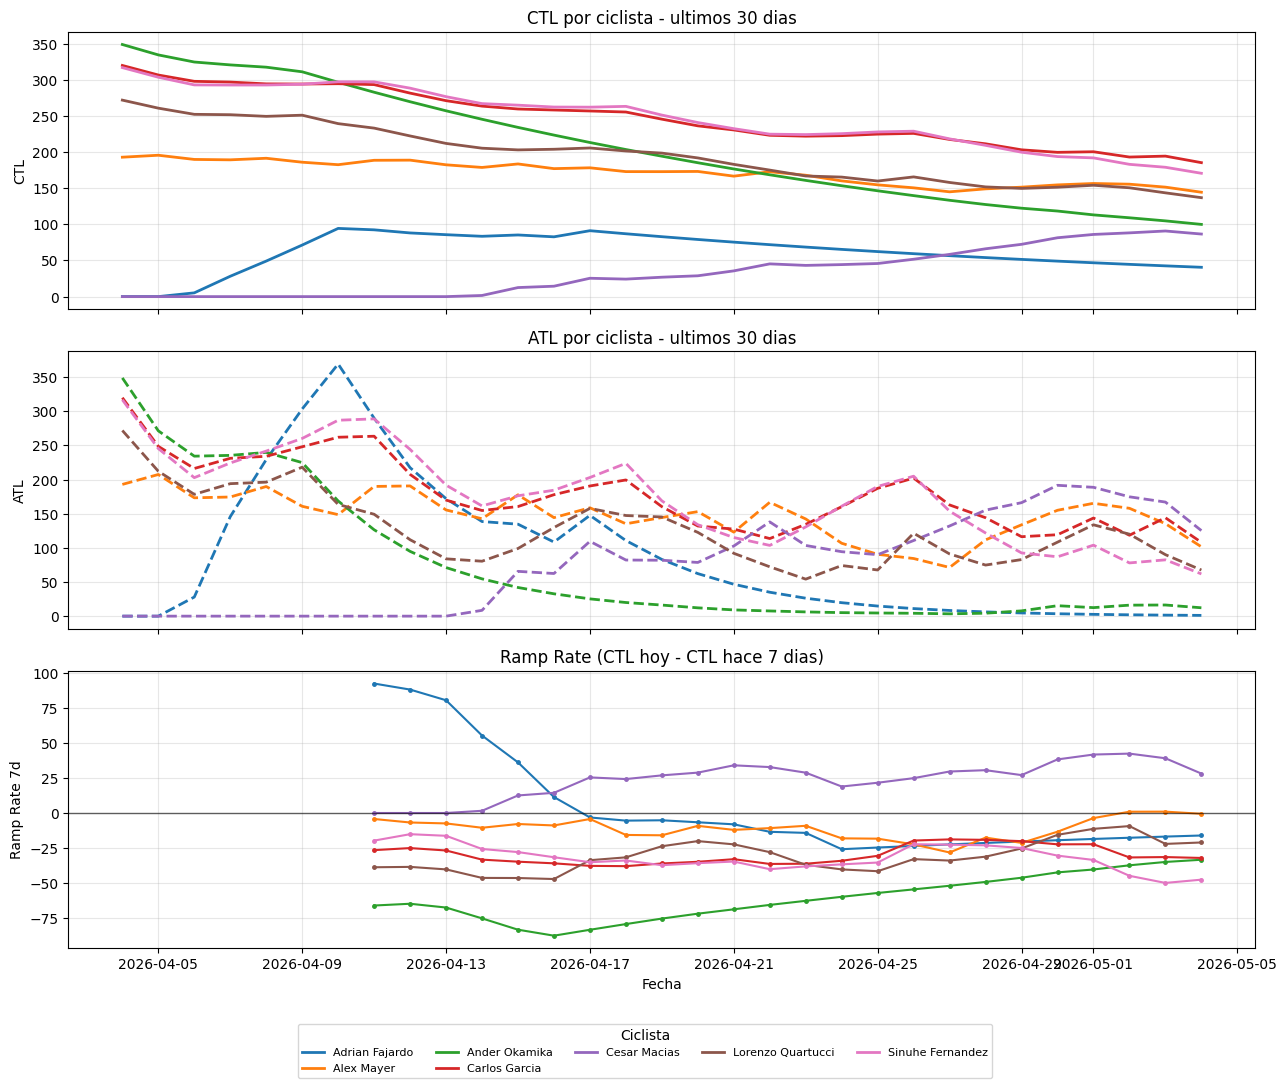

,fecha,athlete_name,daily_load,ctl,atl,ramp_rate_7d
197,2026-04-15,Ander Okamika,4.0,234.255749,41.969109,-83.345448
198,2026-04-16,Ander Okamika,5.0,223.592691,32.726832,-87.608450
199,2026-04-17,Ander Okamika,3.0,213.332566,25.295124,-83.394104
200,2026-04-18,Ander Okamika,4.0,203.596167,19.971343,-79.329262
201,2026-04-19,Ander Okamika,5.0,194.359136,16.228507,-75.406970
202,2026-04-20,Ander Okamika,0.0,185.319177,12.171380,-71.899669
203,2026-04-21,Ander Okamika,0.0,176.699680,9.128535,-68.788057
204,2026-04-22,Ander Okamika,3.0,168.620625,7.596401,-65.635124
205,2026-04-23,Ander Okamika,2.0,160.870829,6.197301,-62.721862
206,2026-04-24,Ander Okamika,2.0,153.481488,5.147976,-59.851078


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Requiere que existan api_key y atletas (de celdas anteriores)
if 'api_key' not in globals():
    raise ValueError("No existe api_key. Ejecuta primero la celda de autenticacion.")

if 'atletas' not in globals() or not atletas:
    raise ValueError("No existe la lista de atletas. Ejecuta primero la celda que carga athlete-summary.")

auth = HTTPBasicAuth('API_KEY', api_key)
meta_burgos = pd.read_csv('data/burgos.csv', sep=';')
meta_burgos['intervals_id'] = meta_burgos['intervals_id'].astype(str)
nombres_burgos = dict(zip(meta_burgos['intervals_id'], meta_burgos['Name']))

# Para calcular bien CTL/ATL en ultimos 30 dias, tomamos una ventana de carga mas larga
hoy = datetime.now().date()
fecha_inicio_plot = hoy - timedelta(days=30)
fecha_inicio_carga = hoy - timedelta(days=30)

fechas_completas = pd.date_range(start=fecha_inicio_carga, end=hoy, freq='D')
resultado = []

for atleta in atletas:
    athlete_id = str(atleta.get('athlete_id'))
    nombre_api = atleta.get('athlete_name', f"athlete_{athlete_id}")
    nombre = nombres_burgos.get(athlete_id, nombre_api)

    url_acts = (
        f"https://intervals.icu/api/v1/athlete/{athlete_id}/activities"
        f"?oldest={fecha_inicio_carga}&newest={hoy}"
    )
    r = requests.get(url_acts, auth=auth)

    if r.status_code != 200:
        print(f"No se pudieron cargar actividades de {nombre} (status {r.status_code})")
        continue

    json_data = r.json()
    acts = json_data if isinstance(json_data, list) else []
    if not acts:
        continue

    rows = []
    for act in acts:
        fecha_txt = act.get('start_date_local') or act.get('start_date')
        if not fecha_txt:
            continue

        fecha = pd.to_datetime(fecha_txt, errors='coerce')
        if pd.isna(fecha):
            continue

        load = act.get('icu_training_load')
        if load is None:
            load = act.get('training_load')
        if load is None:
            load = 0

        rows.append({"fecha": fecha.date(), "load": float(load)})

    if not rows:
        continue

    df = pd.DataFrame(rows)
    df_diario = (
        df.groupby('fecha', as_index=False)['load']
        .sum()
        .rename(columns={'load': 'daily_load'})
    )

    serie = pd.DataFrame({'fecha': fechas_completas.date})
    serie = serie.merge(df_diario, on='fecha', how='left')
    serie['daily_load'] = serie['daily_load'].fillna(0.0)

    # CTL y ATL con medias exponenciales clasicas
    serie['ctl'] = serie['daily_load'].ewm(span=42, adjust=False).mean()
    serie['atl'] = serie['daily_load'].ewm(span=7, adjust=False).mean()

    # Ramp Rate diario: cambio de CTL respecto a hace 7 dias
    serie['ramp_rate_7d'] = serie['ctl'] - serie['ctl'].shift(7)

    serie['athlete_name'] = nombre
    serie_30 = serie[serie['fecha'] >= fecha_inicio_plot].copy()
    resultado.append(serie_30)

if not resultado:
    raise ValueError("No se encontraron datos para calcular CTL/ATL/Ramp Rate.")

metrics_df = pd.concat(resultado, ignore_index=True)
metrics_df['fecha'] = pd.to_datetime(metrics_df['fecha'])

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# Mantener colores consistentes por ciclista en los 3 paneles
nombres = sorted(metrics_df['athlete_name'].unique())
palette = plt.cm.tab10.colors
color_map = {nombre: palette[i % len(palette)] for i, nombre in enumerate(nombres)}

# Panel 1: CTL
for nombre, g in metrics_df.groupby('athlete_name'):
    axes[0].plot(g['fecha'], g['ctl'], linewidth=2, color=color_map[nombre], label=nombre)

axes[0].set_title('CTL por ciclista - ultimos 30 dias')
axes[0].set_ylabel('CTL')          
axes[0].grid(True, alpha=0.3)

# Panel 2: ATL
for nombre, g in metrics_df.groupby('athlete_name'):
    axes[1].plot(g['fecha'], g['atl'], linewidth=2, linestyle='--', color=color_map[nombre])

axes[1].set_title('ATL por ciclista - ultimos 30 dias')
axes[1].set_ylabel('ATL')
axes[1].grid(True, alpha=0.3)

# Panel 3: Ramp Rate
for nombre, g in metrics_df.groupby('athlete_name'):
    axes[2].plot(g['fecha'], g['ramp_rate_7d'], marker='o', markersize=2.5, linewidth=1.5, color=color_map[nombre])

axes[2].axhline(0, color='black', linewidth=1, alpha=0.6)
axes[2].set_title('Ramp Rate (CTL hoy - CTL hace 7 dias)')
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Ramp Rate 7d')
axes[2].grid(True, alpha=0.3)

# Una sola leyenda global en la parte inferior
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Ciclista', ncol=5, fontsize=8, loc='lower center', bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

metrics_df[['fecha', 'athlete_name', 'daily_load', 'ctl', 'atl', 'ramp_rate_7d']].tail(20)

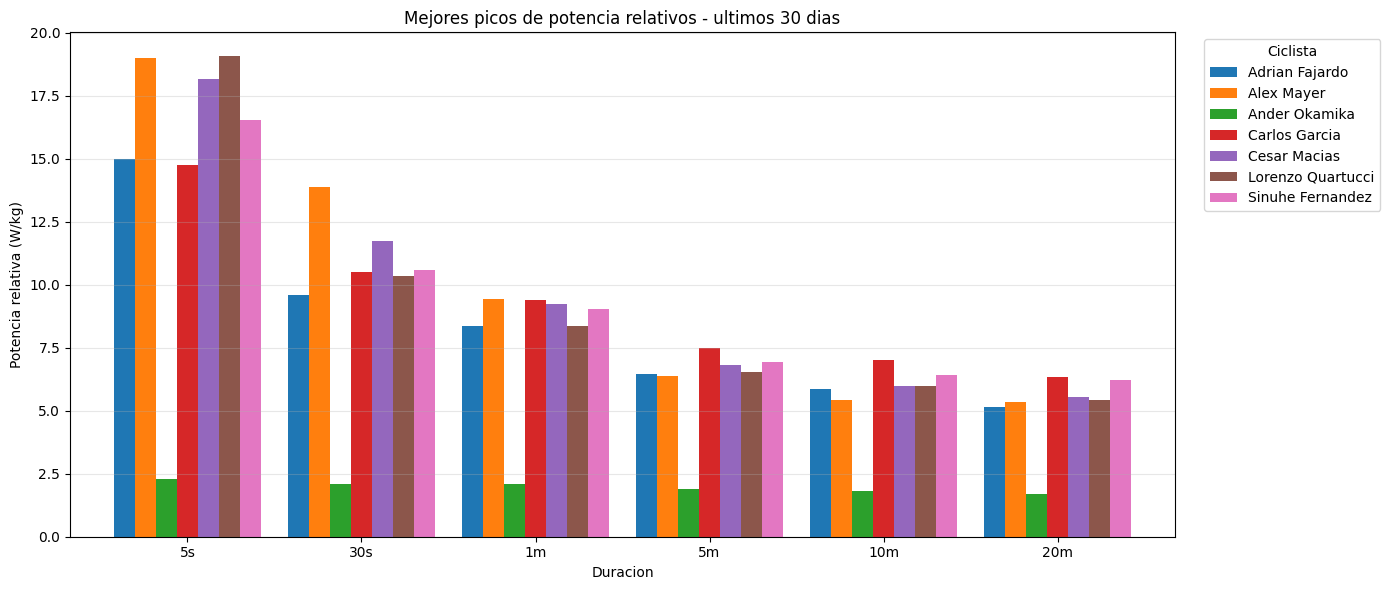

,athlete_id,athlete_name,weight_kg,duration_s,duration_label,peak_watts,peak_wkg,peak_date
0,i547906,Adrian Fajardo,63,5,5s,944,14.98,2026-04-17
1,i547906,Adrian Fajardo,63,30,30s,604,9.59,2026-04-17
2,i547906,Adrian Fajardo,63,60,1m,528,8.38,2026-04-17
3,i547906,Adrian Fajardo,63,300,5m,406,6.44,2026-04-11
4,i547906,Adrian Fajardo,63,600,10m,369,5.86,2026-04-11
5,i547906,Adrian Fajardo,63,1200,20m,324,5.14,2026-04-11
6,i93850,Alex Mayer,64,5,5s,1215,18.98,2026-04-28
7,i93850,Alex Mayer,64,30,30s,889,13.89,2026-04-28
8,i93850,Alex Mayer,64,60,1m,605,9.45,2026-04-28
9,i93850,Alex Mayer,64,300,5m,409,6.39,2026-04-27


In [15]:
from datetime import datetime, timedelta
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt
import requests

if 'auth' not in globals() or 'atletas' not in globals():
    raise ValueError("Ejecuta primero la celda 2 para cargar autenticacion y atletas.")

oldest_30 = (datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')
newest_30 = datetime.now().strftime('%Y-%m-%d')

meta_burgos = pd.read_csv('data/burgos.csv', sep=';')
meta_burgos['intervals_id'] = meta_burgos['intervals_id'].astype(str)
meta_burgos['weight'] = pd.to_numeric(meta_burgos['weight'], errors='coerce')
meta_burgos = meta_burgos.rename(columns={'Name': 'display_name', 'weight': 'weight_kg'})
meta_burgos = meta_burgos[['intervals_id', 'display_name', 'weight_kg']]

# Duraciones objetivo en segundos para picos de potencia
duraciones = [5, 30, 60, 300, 600, 1200]
labels_duracion = {
    5: '5s',
    30: '30s',
    60: '1m',
    300: '5m',
    600: '10m',
    1200: '20m',
}

resultados = []
max_actividades_por_atleta = 20

for atleta in atletas:
    athlete_id = str(atleta.get('athlete_id'))
    athlete_name = atleta.get('athlete_name', athlete_id)

    meta_row = meta_burgos[meta_burgos['intervals_id'] == athlete_id]
    if meta_row.empty:
        print(f"No se encontró {athlete_name} en burgos.csv")
        continue

    display_name = meta_row.iloc[0]['display_name']
    weight_kg = meta_row.iloc[0]['weight_kg']
    if pd.isna(weight_kg) or weight_kg <= 0:
        print(f"Peso no válido para {display_name} en burgos.csv")
        continue

    url_actividades = (
        f"https://intervals.icu/api/v1/athlete/{athlete_id}/activities"
        f"?oldest={oldest_30}&newest={newest_30}"
    )

    try:
        r = requests.get(url_actividades, auth=auth, timeout=25)
    except requests.RequestException:
        print(f"No se pudieron leer actividades de {display_name}")
        continue

    if r.status_code != 200:
        print(f"No se pudieron leer actividades de {display_name} ({r.status_code})")
        continue

    json_acts = r.json()
    actividades_30 = json_acts if isinstance(json_acts, list) else []
    if not actividades_30:
        continue

    # Guardar mejor valor global por duracion para el atleta
    mejores_atleta = {d: None for d in duraciones}
    mejores_atleta_fecha = {d: None for d in duraciones}

    for act in actividades_30[:max_actividades_por_atleta]:
        id_actividad = act.get('id')
        if not id_actividad:
            continue

        # Extraer solo la fecha (YYYY-MM-DD) de la actividad
        act_fecha = (act.get('start_date_local') or act.get('start_date') or '')[:10]

        url_power = f"https://intervals.icu/api/v1/activity/{id_actividad}/power-curve.csv"

        try:
            r_power = requests.get(url_power, auth=auth, timeout=25)
        except requests.RequestException:
            continue

        if r_power.status_code != 200:
            continue

        try:
            df_curve = pd.read_csv(StringIO(r_power.text))
        except Exception:
            continue

        cols = {c.lower(): c for c in df_curve.columns}
        sec_col = next((cols[c] for c in cols if 'sec' in c), None)
        watts_col = next((cols[c] for c in cols if 'watt' in c or c == 'w'), None)

        if sec_col is None or watts_col is None:
            continue

        df_curve[sec_col] = pd.to_numeric(df_curve[sec_col], errors='coerce')
        df_curve[watts_col] = pd.to_numeric(df_curve[watts_col], errors='coerce')
        df_curve = df_curve.dropna(subset=[sec_col, watts_col])

        for d in duraciones:
            fila = df_curve[df_curve[sec_col] == d]
            if fila.empty:
                continue
            val = float(fila[watts_col].max())
            if mejores_atleta[d] is None or val > mejores_atleta[d]:
                mejores_atleta[d] = val
                mejores_atleta_fecha[d] = act_fecha

    for d in duraciones:
        peak_watts = mejores_atleta[d]
        peak_wkg = (peak_watts / weight_kg) if peak_watts is not None else None
        resultados.append(
            {
                'athlete_id': athlete_id,
                'athlete_name': display_name,
                'weight_kg': weight_kg,
                'duration_s': d,
                'duration_label': labels_duracion[d],
                'peak_watts': peak_watts,
                'peak_wkg': peak_wkg,
                'peak_date': mejores_atleta_fecha[d],
            }
        )

peaks_df = pd.DataFrame(resultados)
if peaks_df.empty:
    raise ValueError('No se encontraron picos de potencia en los ultimos 30 dias.')

peaks_df['peak_watts'] = pd.array(
    pd.to_numeric(peaks_df['peak_watts'], errors='coerce').round(),
    dtype='Int64'
)
peaks_df['peak_wkg'] = pd.to_numeric(peaks_df['peak_wkg'], errors='coerce').round(2)

# Mantener solo filas con valor valido para graficar
plot_df = peaks_df.dropna(subset=['peak_wkg']).copy()
if plot_df.empty:
    raise ValueError('No hay datos validos de potencia para las duraciones objetivo.')

pivot = plot_df.pivot_table(
    index='duration_label',
    columns='athlete_name',
    values='peak_wkg',
    aggfunc='max'
).reindex([labels_duracion[d] for d in duraciones])

ax = pivot.plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set_title('Mejores picos de potencia relativos - ultimos 30 dias')
ax.set_xlabel('Duracion')
ax.set_ylabel('Potencia relativa (W/kg)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.legend(title='Ciclista', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Resumen en tabla
peaks_df.sort_values(['athlete_name', 'duration_s']).reset_index(drop=True)


In [16]:
# Tabla de resultados de la celda 9 en formato matriz
if 'peaks_df' not in globals() or peaks_df.empty:
    raise ValueError("No hay datos de picos. Ejecuta primero la celda 9.")

tabla_watts = (
    peaks_df.pivot_table(
        index='duration_label',
        columns='athlete_name',
        values='peak_watts',
        aggfunc='max'
    )
    .reindex(['5s', '30s', '1m', '5m', '10m', '20m'])
)

tabla_wkg = (
    peaks_df.pivot_table(
        index='duration_label',
        columns='athlete_name',
        values='peak_wkg',
        aggfunc='max'
    )
    .reindex(['5s', '30s', '1m', '5m', '10m', '20m'])
)

# Para la fecha tomamos la del pico de mayor potencia por atleta/duración
tabla_fecha = (
    peaks_df.dropna(subset=['peak_watts'])
    .sort_values('peak_watts', ascending=False)
    .drop_duplicates(subset=['duration_label', 'athlete_name'])
    .pivot_table(
        index='duration_label',
        columns='athlete_name',
        values='peak_date',
        aggfunc='first'
    )
    .reindex(['5s', '30s', '1m', '5m', '10m', '20m'])
)

tabla_peaks = tabla_watts.copy().astype(object)

for fila in tabla_peaks.index:
    for columna in tabla_peaks.columns:
        watts = tabla_watts.loc[fila, columna]
        wkg = tabla_wkg.loc[fila, columna]
        fecha = tabla_fecha.loc[fila, columna] if columna in tabla_fecha.columns else None
        fecha_str = f"\n({fecha})" if fecha and not (isinstance(fecha, float) and pd.isna(fecha)) else ""
        if pd.isna(watts) and pd.isna(wkg):
            tabla_peaks.loc[fila, columna] = ''
        elif pd.isna(watts):
            tabla_peaks.loc[fila, columna] = f"{wkg:.1f} W/kg{fecha_str}"
        elif pd.isna(wkg):
            tabla_peaks.loc[fila, columna] = f"{int(watts)} W{fecha_str}"
        else:
            tabla_peaks.loc[fila, columna] = f"{int(watts)} W | {wkg:.1f} W/kg{fecha_str}"

tabla_peaks.index.name = 'potencia'
tabla_peaks


athlete_name,Adrian Fajardo,Alex Mayer,Ander Okamika,Carlos Garcia,Cesar Macias,Lorenzo Quartucci,Sinuhe Fernandez
potencia,,,,,,,
5s,944 W | 15.0 W/kg\n(2026-04-17),1215 W | 19.0 W/kg\n(2026-04-28),161 W | 2.3 W/kg\n(2026-05-03),856 W | 14.8 W/kg\n(2026-04-26),1036 W | 18.2 W/kg\n(2026-04-27),1220 W | 19.1 W/kg\n(2026-04-15),992 W | 16.5 W/kg\n(2026-04-23)
30s,604 W | 9.6 W/kg\n(2026-04-17),889 W | 13.9 W/kg\n(2026-04-28),148 W | 2.1 W/kg\n(2026-05-03),610 W | 10.5 W/kg\n(2026-04-25),668 W | 11.7 W/kg\n(2026-04-15),663 W | 10.4 W/kg\n(2026-04-17),635 W | 10.6 W/kg\n(2026-04-18)
1m,528 W | 8.4 W/kg\n(2026-04-17),605 W | 9.4 W/kg\n(2026-04-28),146 W | 2.1 W/kg\n(2026-05-03),546 W | 9.4 W/kg\n(2026-04-25),527 W | 9.2 W/kg\n(2026-05-03),535 W | 8.4 W/kg\n(2026-04-17),543 W | 9.1 W/kg\n(2026-04-18)
5m,406 W | 6.4 W/kg\n(2026-04-11),409 W | 6.4 W/kg\n(2026-04-27),133 W | 1.9 W/kg\n(2026-05-03),433 W | 7.5 W/kg\n(2026-04-16),389 W | 6.8 W/kg\n(2026-04-27),418 W | 6.5 W/kg\n(2026-04-18),417 W | 7.0 W/kg\n(2026-04-23)
10m,369 W | 5.9 W/kg\n(2026-04-11),347 W | 5.4 W/kg\n(2026-04-22),126 W | 1.8 W/kg\n(2026-05-03),406 W | 7.0 W/kg\n(2026-04-16),342 W | 6.0 W/kg\n(2026-04-30),383 W | 6.0 W/kg\n(2026-04-17),384 W | 6.4 W/kg\n(2026-04-23)
20m,324 W | 5.1 W/kg\n(2026-04-11),342 W | 5.3 W/kg\n(2026-04-22),120 W | 1.7 W/kg\n(2026-05-03),367 W | 6.3 W/kg\n(2026-04-24),317 W | 5.6 W/kg\n(2026-04-30),346 W | 5.4 W/kg\n(2026-04-16),372 W | 6.2 W/kg\n(2026-04-24)


PDF CON MEJORES POTENCIAS DE LOS ULTIMOS 30 DIAS,CTL Y ATL

In [17]:
from datetime import datetime
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

if 'plot_df' not in globals() or plot_df.empty:
    raise ValueError("No hay datos del grafico de potencias. Ejecuta primero la celda 9.")

if 'tabla_peaks' not in globals() or tabla_peaks.empty:
    raise ValueError("No hay tabla de potencias. Ejecuta primero la celda 10.")

if 'metrics_df' not in globals() or metrics_df.empty:
    raise ValueError("No hay datos de CTL/ATL. Ejecuta primero la celda 8.")

output_pdf = Path('intervals_informe.pdf')
logo_path = Path('LOGO.png')
orden_duraciones = ['5s', '30s', '1m', '5m', '10m', '20m']

pivot_pdf = plot_df.pivot_table(
    index='duration_label',
    columns='athlete_name',
    values='peak_wkg',
    aggfunc='max'
).reindex(orden_duraciones)

tabla_pdf = tabla_peaks.fillna('').astype(str)
nombres_metricas = sorted(metrics_df['athlete_name'].dropna().unique())
palette = plt.cm.tab10.colors
color_map_pdf = {
    nombre: palette[i % len(palette)]
    for i, nombre in enumerate(nombres_metricas)
}

logo_img = plt.imread(logo_path) if logo_path.exists() else None


def add_header(ax, titulo, subtitulo):
    ax.axis('off')
    if logo_img is not None:
        ax.imshow(logo_img)
        ax.set_aspect('equal')
    ax.text(
        1.02,
        0.68,
        titulo,
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='center'
    )
    ax.text(
        1.02,
        0.28,
        subtitulo,
        transform=ax.transAxes,
        fontsize=10,
        color='dimgray',
        va='center'
    )


def ajustar_anchos_tabla(table, tabla_df):
    pesos = [max(10, len(str(tabla_df.index.name or 'potencia')) + 2)]
    for columna in tabla_df.columns:
        max_contenido = max(tabla_df[columna].map(len).max(), len(str(columna)))
        pesos.append(max(12, max_contenido + 2))

    ancho_total = 0.98
    escala = ancho_total / sum(pesos)
    anchos = [peso * escala for peso in pesos]

    for fila in range(1, len(tabla_df.index) + 1):
        table[(fila, -1)].set_width(anchos[0])

    for columna in range(len(tabla_df.columns)):
        table[(0, columna)].set_width(anchos[columna + 1])
        for fila in range(1, len(tabla_df.index) + 1):
            table[(fila, columna)].set_width(anchos[columna + 1])


def crear_pagina_potencias(pdf):
    fig_ancho = max(17, 7 + sum(max(12, max(tabla_pdf[col].map(len).max(), len(str(col))) + 2) for col in tabla_pdf.columns) * 0.16)
    fig_alto = max(12, 7 + len(tabla_pdf.index) * 0.55)
    fig_power = plt.figure(figsize=(fig_ancho, fig_alto), constrained_layout=True)
    gs_power = fig_power.add_gridspec(3, 1, height_ratios=[0.8, 3.3, 2.5])

    ax_header_power = fig_power.add_subplot(gs_power[0])
    add_header(ax_header_power, 'Informe de potencias', 'Grafico de picos y tabla resumen')

    ax_plot = fig_power.add_subplot(gs_power[1])
    pivot_pdf.plot(kind='bar', ax=ax_plot, width=0.85)
    ax_plot.set_title('Mejores picos de potencia relativos - ultimos 30 dias')
    ax_plot.set_xlabel('Duracion')
    ax_plot.set_ylabel('Potencia relativa (W/kg)')
    ax_plot.grid(axis='y', alpha=0.3)
    ax_plot.tick_params(axis='x', rotation=0)
    ax_plot.legend(title='Ciclista', bbox_to_anchor=(1.01, 1), loc='upper left')

    ax_table = fig_power.add_subplot(gs_power[2])
    ax_table.axis('off')
    ax_table.set_title('Tabla de potencias', fontsize=14, pad=12)
    table = ax_table.table(
        cellText=tabla_pdf.values,
        rowLabels=tabla_pdf.index.tolist(),
        colLabels=tabla_pdf.columns.tolist(),
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.45)
    ajustar_anchos_tabla(table, tabla_pdf)

    pdf.savefig(fig_power, bbox_inches='tight')
    plt.close(fig_power)


def crear_pagina_carga(pdf):
    fig_load = plt.figure(figsize=(15, 10), constrained_layout=True)
    gs_load = fig_load.add_gridspec(3, 1, height_ratios=[0.8, 2.3, 2.3])

    ax_header_load = fig_load.add_subplot(gs_load[0])
    add_header(ax_header_load, 'Informe de carga', 'CTL y ATL por ciclista')

    ax_ctl = fig_load.add_subplot(gs_load[1])
    for nombre, g in metrics_df.groupby('athlete_name'):
        ax_ctl.plot(g['fecha'], g['ctl'], linewidth=2, color=color_map_pdf[nombre], label=nombre)
    ax_ctl.set_title('CTL por ciclista')
    ax_ctl.set_ylabel('CTL')
    ax_ctl.grid(True, alpha=0.3)
    ax_ctl.legend(title='Ciclista', bbox_to_anchor=(1.01, 1), loc='upper left')

    ax_atl = fig_load.add_subplot(gs_load[2], sharex=ax_ctl)
    for nombre, g in metrics_df.groupby('athlete_name'):
        ax_atl.plot(g['fecha'], g['atl'], linewidth=2, linestyle='--', color=color_map_pdf[nombre])
    ax_atl.set_title('ATL por ciclista')
    ax_atl.set_xlabel('Fecha')
    ax_atl.set_ylabel('ATL')
    ax_atl.grid(True, alpha=0.3)

    pdf.savefig(fig_load, bbox_inches='tight')
    plt.close(fig_load)


def crear_informe(pdf):
    crear_pagina_potencias(pdf)
    crear_pagina_carga(pdf)


output_final = output_pdf
try:
    with PdfPages(output_final) as pdf:
        crear_informe(pdf)
except PermissionError:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_final = Path(f'intervals_informe_{timestamp}.pdf')
    with PdfPages(output_final) as pdf:
        crear_informe(pdf)

print(f"PDF generado en: {output_final.resolve()}")
output_final.resolve()

PDF generado en: C:\Users\echav\OneDrive\Documentos\GitHub\procyclingstats\intervals_informe.pdf


WindowsPath('C:/Users/echav/OneDrive/Documentos/GitHub/procyclingstats/intervals_informe.pdf')